In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

In [2]:
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn",)

numpy 2.4.4
pandas 3.0.2
sklearn


In [3]:
df = pd.read_csv(r"C:\Users\lenovo\Downloads\WineQT.csv")
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [4]:
df1 = df.copy()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [8]:
df.drop('Id',axis=1,inplace=True)

In [9]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(125)

In [11]:
df.drop_duplicates().sum()

fixed acidity            8437.70000
volatile acidity          543.14500
citric acid               273.64000
residual sugar           2569.85000
chlorides                  88.75600
free sulfur dioxide     15930.50000
total sulfur dioxide    47159.50000
density                  1014.64013
pH                       3371.11000
sulphates                 668.64000
alcohol                 10640.60000
quality                  5743.00000
dtype: float64

In [12]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [13]:
(df==0).sum()

fixed acidity            0
volatile acidity         0
citric acid             99
residual sugar           0
chlorides                0
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       0
sulphates                0
alcohol                  0
quality                  0
dtype: int64

In [14]:
df['quality_label'] = pd.cut(
    df['quality'],
    bins=[0, 4, 6, 10],
    labels=[0, 1, 2]
)

df['quality_label'] = df['quality_label'].astype(int)

In [15]:
print(df[['quality', 'quality_label']].head())
print(df['quality_label'].value_counts())

   quality  quality_label
0        5              1
1        5              1
2        5              1
3        6              1
4        5              1
quality_label
1    945
2    159
0     39
Name: count, dtype: int64


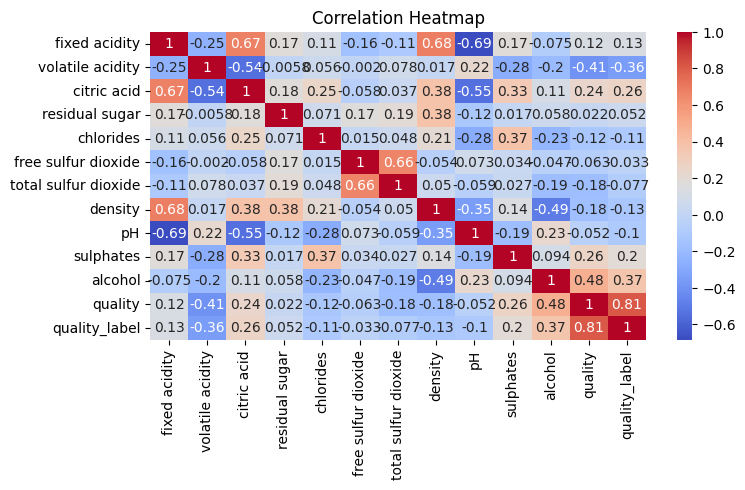

In [16]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
df.skew()

fixed acidity           1.044930
volatile acidity        0.681547
citric acid             0.371561
residual sugar          4.361096
chlorides               6.026360
free sulfur dioxide     1.231261
total sulfur dioxide    1.665766
density                 0.102395
pH                      0.221138
sulphates               2.497266
alcohol                 0.863313
quality                 0.286792
quality_label           0.808387
dtype: float64

In [18]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print(outliers.sum())

fixed acidity            44
volatile acidity         14
citric acid               1
residual sugar          110
chlorides                77
free sulfur dioxide      18
total sulfur dioxide     40
density                  36
pH                       20
sulphates                43
alcohol                  12
quality                  22
quality_label           198
dtype: int64


In [19]:
Q1 = df.drop('quality', axis=1).quantile(0.25)
Q3 = df.drop('quality', axis=1).quantile(0.75)

IQR = Q3 - Q1

df_clean = df[~((df.drop('quality', axis=1) < (Q1 - 1.5 * IQR)) | 
                (df.drop('quality', axis=1) > (Q3 + 1.5 * IQR))).any(axis=1)]

In [20]:
print("Before:", df.shape)

Before: (1143, 13)


In [21]:
print("After:", df_clean.shape)

After: (721, 13)


In [22]:
# df = pd.get_dummies(df, drop_first= True) # One Hot Encoding

In [23]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [25]:
corr = pd.concat([X, y], axis=1).corr()
print(corr['quality_label'].sort_values(ascending=False))

quality_label           1.000000
alcohol                 0.516494
citric acid             0.456937
sulphates               0.288604
fixed acidity           0.223988
residual sugar          0.049024
free sulfur dioxide     0.028605
total sulfur dioxide   -0.017423
chlorides              -0.184483
density                -0.200093
pH                     -0.276830
volatile acidity       -0.652211
Name: quality_label, dtype: float64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score

# Use new target
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE (before scaling ✔)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, rf_pred))
print(f"RF Accuracy : {accuracy_score(y_test,rf_pred)}")
print(f"RF F1 Score : {f1_score(y_test,rf_pred, average='micro')}")

# XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1)

xgb.fit(X_train, y_train)   # ✅ important
xgb_pred = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, xgb_pred))
print(f"XGBoost Accuracy : {accuracy_score(y_test,xgb_pred)}")
print(f"XGBoost F1 Score : {f1_score(y_test,xgb_pred, average='macro')}")

Random Forest
              precision    recall  f1-score   support

           0       0.10      0.12      0.11         8
           1       0.93      0.88      0.90       189
           2       0.66      0.84      0.74        32

    accuracy                           0.85       229
   macro avg       0.56      0.62      0.59       229
weighted avg       0.87      0.85      0.85       229

RF Accuracy : 0.8471615720524017
RF F1 Score : 0.8471615720524017
XGBoost
              precision    recall  f1-score   support

           0       0.18      0.25      0.21         8
           1       0.93      0.88      0.91       189
           2       0.66      0.78      0.71        32

    accuracy                           0.85       229
   macro avg       0.59      0.64      0.61       229
weighted avg       0.86      0.85      0.85       229

XGBoost Accuracy : 0.8471615720524017
XGBoost F1 Score : 0.6099870271885677


In [ ]:
# ==================================
# WineQT model = using Pipeline
# ==================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score

from IPython.display import display

# wine_data = pd.read_csv(r"C:\Users\lenovo\Downloads\WineQT.csv")

X = wine_data.drop('quality',axis=1)
y = wine_data['quality']
y = pd.cut(
    wine_data['quality'],
    bins=[0, 4, 6, 10],
    labels=[0, 1, 2]
).astype(int)

xtrain,xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2,random_state=1)

df['quality_label'] = df['quality_label'].astype(int)

num_col = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']


num_pipe = Pipeline([
    ("impute",SimpleImputer(strategy='median')),
    ('skew',PowerTransformer('yeo-johnson')),
    ("scale",StandardScaler())
])



process = ColumnTransformer([
    ('num',num_pipe,num_col)
])


model = Pipeline([
  ('process',process),
  ('model',RandomForestClassifier())
])

model.fit(xtrain,ytrain)
rand_pred = model.predict(xtest)

acc = accuracy_score(ytest,rand_pred)
f1 = f1_score(ytest,rand_pred,average='micro')

print(f"Accuracy  : {acc}")
print(f"F1 Score  : {f1}")

display(process)



Accuracy  : 0.8480392156862745
F1 Score  : 0.8480392156862745


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('skew', PowerTransformer()),
                                                 ('scale', StandardScaler())]),
                                 ['fixed acidity', 'volatile acidity',
                                  'citric acid', 'residual sugar', 'chlorides',
                                  'free sulfur dioxide', 'total sulfur dioxide',
                                  'density', 'pH', 'sulphates', 'alcohol'])])